In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
ds = pd.read_csv('USA_Housing.csv')

In [4]:
ds

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


In [5]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [7]:
ds = ds.drop('Address', axis=1)

In [8]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [10]:
ds = ds.dropna()

In [11]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [13]:
#Spilit Data to use in Model
# Price is Output and trarget variable
y = ds.Price
# Create Matrix of features and Input
x = ds.drop('Price',axis=1)

In [14]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [32]:
#spilit data for train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_transform, y, test_size= .20 ,random_state=101)

In [16]:
x_train

array([[ 0.33021585, -0.83785628,  0.56884126, -0.39005235, -1.74758952],
       [-0.19689213, -0.27874646, -0.07847136, -0.47108872, -0.82228217],
       [ 0.91052612, -1.75551415,  0.47462373,  1.06049864,  0.63097999],
       ...,
       [-1.21622414, -2.26082045, -0.11881994, -1.36248876,  2.72262263],
       [-0.51972297, -0.04232647, -1.06821454,  0.09616586, -0.34643377],
       [ 0.60952689,  1.68209486,  1.44465262,  0.2825495 ,  2.01366478]],
      shape=(3750, 5))

In [17]:
y_train

3430    9.958132e+05
3979    8.735092e+05
2153    1.360502e+06
4764    1.742351e+06
36      1.233220e+06
            ...     
4171    7.296417e+05
599     1.599479e+06
1361    1.102641e+06
1547    8.650995e+05
4959    2.108376e+06
Name: Price, Length: 3750, dtype: float64

Model Traning

In [18]:
from sklearn.linear_model import LinearRegression
#Create Instance of Model
lin_reg =  LinearRegression()
# Give Train in Regration
lin_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model Tesing

In [19]:
#Predict
y_pred = lin_reg.predict(x_test)
y_pred

array([1258816.37337318,  823463.99816306, 1741498.0262734 , ...,
       1117876.18477598,  720574.23077619, 1516900.35119194],
      shape=(1250,))

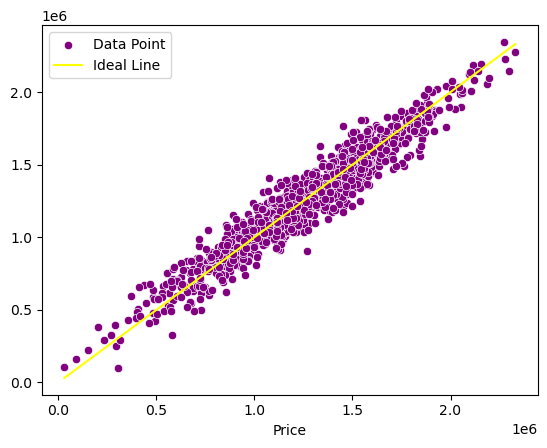

In [27]:
sns.scatterplot(x= y_test , y=y_pred, color='Purple', label='Data Point')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color= 'Yellow', label= 'Ideal Line')
plt.legend()

In [29]:
# Combine Actual and predict value  price side by side 
results = np.column_stack((y_test,y_pred))
#Print Result
print('Actual Price  |  Predict Price')
print('-------------------------------')
for actual, predict in results:
    print(f'{actual:14.2f} | {predict:12.2f}')

Actual Price  |  Predict Price
-------------------------------
    1251688.62 |   1258816.37
     873048.32 |    823464.00
    1696977.66 |   1741498.03
    1063964.29 |    972475.26
     948788.28 |    995644.61
     730043.65 |    644510.29
    1166925.15 |   1078125.44
     705444.12 |    854514.08
    1499988.88 |   1444898.64
    1288199.15 |   1203443.42
    1441736.76 |   1455483.73
    1279681.15 |   1298715.15
    1754969.16 |   1735995.86
    1511653.45 |   1337566.01
    1441956.20 |   1389223.94
    1119992.62 |   1223974.81
     727866.53 |    615338.73
    1138885.10 |    964398.51
    1074263.32 |   1221310.00
    1386473.37 |   1198963.20
     404643.60 |    507164.52
    1449829.49 |   1768108.44
    1775874.76 |   1853542.11
    1202050.58 |   1199817.41
    1105737.46 |   1064894.68
    1835564.69 |   1811899.21
    1795428.77 |   1770789.63
    1424283.37 |   1439747.33
    1365945.08 |   1386900.55
    1492011.50 |   1541215.33
     624432.97 |    729584.34
    182

Linear Regration

In [31]:
#Score it it is for regarion only not classification (only regrasor)
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_pred)
rmse =  np.sqrt(mse)

# Print evaluation metrics
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 10364756049.538452
Root Mean Squared Error: 101807.44594349891
